# Decision Trees

Fit a regularized regression tree to predict five-day forward returns.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from tree_model_utils import (
    FEATURES,
    compare_bagging,
    ensure_output_dir,
    fit_decision_tree,
    fit_signal_model,
    long_short_backtest,
    make_equity_panel,
    signal_quality,
    tune_random_forest,
)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
OUTPUT = ensure_output_dir()


In [2]:
panel = make_equity_panel(seed=112)
model, metrics = fit_decision_tree(panel)
pd.Series(metrics).to_frame('value')

,value
test_rmse,0.0382


In [3]:
importance = pd.DataFrame({'feature': FEATURES, 'importance': model.feature_importances_}).sort_values('importance', ascending=False)
importance.to_csv(OUTPUT / 'decision_tree_importance.csv', index=False)
importance

,feature,importance
1,momentum_63,0.2914
2,volatility_21,0.2615
4,sector_beta,0.2003
5,quality,0.1858
0,momentum_21,0.0609
3,reversal_5,0.0000


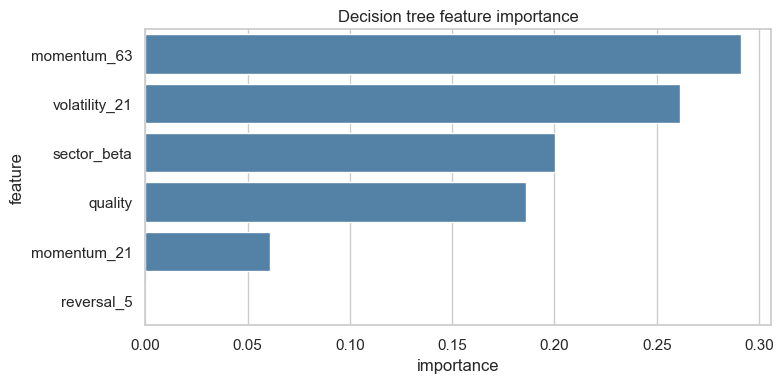

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=importance, x='importance', y='feature', ax=ax, color='steelblue')
ax.set(title='Decision tree feature importance')
plt.tight_layout()